## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"
pert_path = project_dir / "noise_pert.py"

In [2]:
from calculate_metrics import calculate_metrics
from noise_pert import set_seed

In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [4]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")

In [5]:
# TDS Constants
STEP_TIME = 0.001 # 1 ms

In [6]:
ss_true = andes.load(case_path, setup=False)
ss_true.REGF2.set("mf",1, 2)

ss_true.setup()
ss_true.config.warn_abnormal = 0
ss_true.PFlow.run()


ss_true.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss_true.TDS.config.fixt = 1 # fixed step size
ss_true.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss_true.TDS.config.no_tqdm = 1
ss_true.TDS.config.criteria = 1
ss_true.TDS.run()

True

## Run TDS & Initial Results

In [7]:
tr = 0.005
seed_idx = 3
set_seed(seed_idx)

ss = andes.load(case_path, pert=pert_path)
ss.REGF2.set("Tr",1, tr)
ss.REGF2.set("mf",1, 2)
#ss.REGF2.set("Tpm",1, 0.05)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

rng set to: 3


System has been setup. Calling setup() twice is not allowed. To add devices, reload the case with setup=False, add devices, then call setup().


True

In [8]:
def visualize_cf_noise(noisy, true, var, figsize=(6,4), xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_title(f"{var}: Noisy vs. Noiseless Signal Inputs")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"{var} (p.u.)")

    # plot actual
    ax.plot(true.index, true, "s-", color="tab:blue",
                markersize=0.5, label="Noiseless Inputs", alpha=0.8)
    ax.plot(noisy.index, noisy, "s-", color="tab:orange",
                    markersize=0.5, label="Noisy Inputs", alpha=0.8)
    
    

    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

    if xlim != None:
        ax.set_xlim(xlim)

    if ylim != None:
        ax.set_ylim(ylim)

    plt.tight_layout()

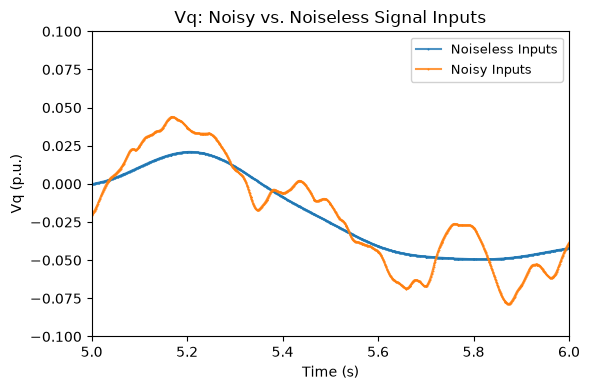

In [9]:
vq = ss.TDS.get_timeseries(ss.REGF2.vq)
vq_t = ss_true.TDS.get_timeseries(ss_true.REGF2.vq)

visualize_cf_noise(vq, vq_t, "Vq", xlim=(5, 6), ylim=(-0.1, 0.1))

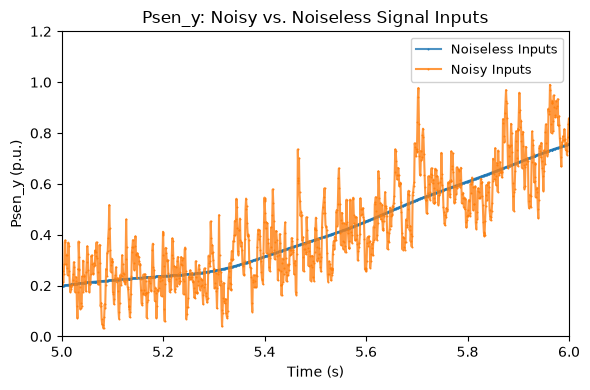

In [10]:
psen = ss.TDS.get_timeseries(ss.REGF2.Psen_y)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Psen_y)

visualize_cf_noise(psen, psen_t, "Psen_y", xlim=(5, 6), ylim=(0, 1.2))

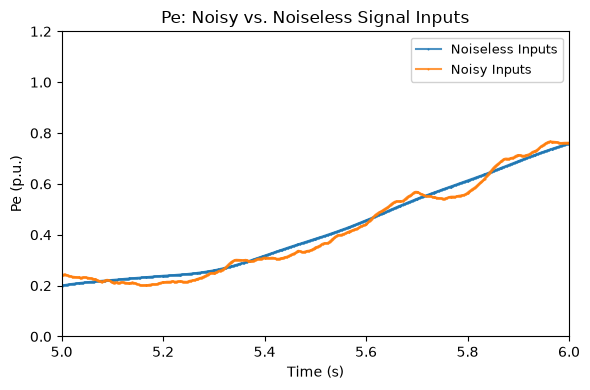

In [11]:
psen = ss.TDS.get_timeseries(ss.REGF2.Pe)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Pe)

visualize_cf_noise(psen, psen_t, "Pe", xlim=(5, 6), ylim=(0, 1.2))

In [12]:
psen

,1
0.000000,0.200000
0.000100,0.199998
0.001100,0.199969
0.002100,0.199998
0.003100,0.200173
...,...
9.997867,0.987820
9.998867,0.987683
9.999867,0.987396
10.000000,0.987346


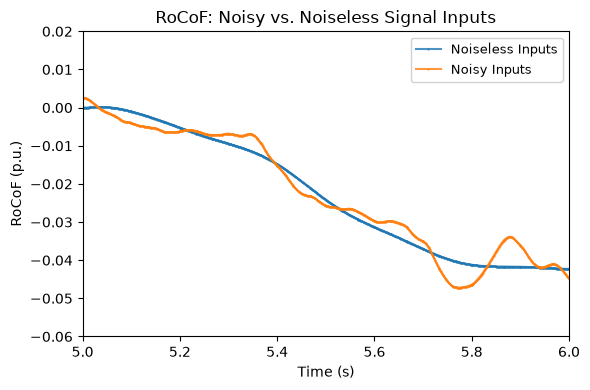

In [13]:
a1 = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
a2 = ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y)

visualize_cf_noise(a1, a2, "RoCoF", xlim=(5, 6), ylim=(-0.06, 0.02))

## Metrics

In [14]:
# anything w/o units is in p.u. 
metrics = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[]
})

# save a few time-series for visualization
M_series = pd.DataFrame({
})

metrics_true = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[]
})

# save a few time-series for visualization
M_series_true = pd.DataFrame({
})

In [15]:
metrics, M_series = calculate_metrics(ss, metrics, M_series, True)
metrics

,Tr (s),Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir
0,0.005,0.2,1.379606,1.5,2.909754,0.047625,0.936023


In [16]:
metrics_true, M_series_true = calculate_metrics(ss_true, metrics_true, M_series_true,True)
metrics_true

,Tr (s),Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir
0,0.005,0.2,1.27519,1.5,2.620119,0.042286,0.93779


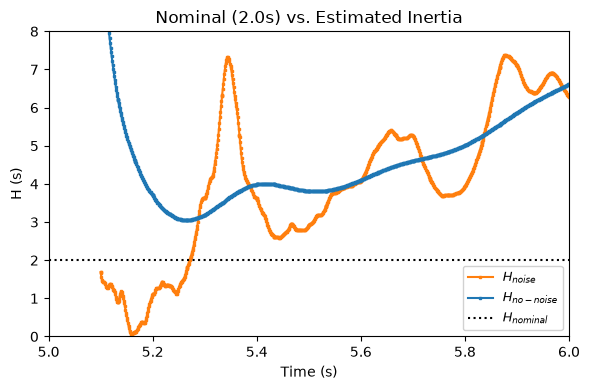

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = M_series

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:orange", markersize=1.8, label = f"$H_{{noise}}$")
ax.plot(M_series_true.index, M_series_true, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{no-noise}}$")


plt.axline((0, H_gfm), slope=0, color="black", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

#ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
plt.xlim(5, 6)
plt.ylim(0, 8)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')